In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
path = "E:\\Data Science Salarys\\Data\\ds_salaries.csv"
df = pd.read_csv(path, sep=",")

In [3]:
df.head()

,Unnamed: 0,work_year,experience_level,employment_type,job_title,salary,salary_currency,salary_in_usd,employee_residence,remote_ratio,company_location,company_size
0,0,2020,MI,FT,Data Scientist,70000,EUR,79833,DE,0,DE,L
1,1,2020,SE,FT,Machine Learning Scientist,260000,USD,260000,JP,0,JP,S
2,2,2020,SE,FT,Big Data Engineer,85000,GBP,109024,GB,50,GB,M
3,3,2020,MI,FT,Product Data Analyst,20000,USD,20000,HN,0,HN,S
4,4,2020,SE,FT,Machine Learning Engineer,150000,USD,150000,US,50,US,L


In [4]:
df.drop(columns=["Unnamed: 0"], inplace=True)

In [5]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 607 entries, 0 to 606
Data columns (total 11 columns):
 #   Column              Non-Null Count  Dtype
---  ------              --------------  -----
 0   work_year           607 non-null    int64
 1   experience_level    607 non-null    str  
 2   employment_type     607 non-null    str  
 3   job_title           607 non-null    str  
 4   salary              607 non-null    int64
 5   salary_currency     607 non-null    str  
 6   salary_in_usd       607 non-null    int64
 7   employee_residence  607 non-null    str  
 8   remote_ratio        607 non-null    int64
 9   company_location    607 non-null    str  
 10  company_size        607 non-null    str  
dtypes: int64(4), str(7)
memory usage: 52.3 KB


In [6]:
df['experience_level'] = df['experience_level'].replace({
    'EN': 'Junior',
    'MI': 'Pleno',
    'SE': 'Senior',
    'EX': 'Executive'
})

df['employment_type'] = df['employment_type'].replace({
    'PT': 'Meio período',
    'FT': 'Tempo integral',
    'CT': 'Contrato',
    'FL': 'Freelancer'
})


df['company_size'] = df['company_size'].replace({
    'S': 'Pequena',
    'M': 'Média',
    'L': 'Grande'
})

df['remote_ratio'] = df['remote_ratio'].replace({
    0: 'Presencial',
    50: 'Híbrido',
    100: 'Remoto'
})

df.head()

,work_year,experience_level,employment_type,job_title,salary,salary_currency,salary_in_usd,employee_residence,remote_ratio,company_location,company_size
0,2020,Pleno,Tempo integral,Data Scientist,70000,EUR,79833,DE,Presencial,DE,Grande
1,2020,Senior,Tempo integral,Machine Learning Scientist,260000,USD,260000,JP,Presencial,JP,Pequena
2,2020,Senior,Tempo integral,Big Data Engineer,85000,GBP,109024,GB,Híbrido,GB,Média
3,2020,Pleno,Tempo integral,Product Data Analyst,20000,USD,20000,HN,Presencial,HN,Pequena
4,2020,Senior,Tempo integral,Machine Learning Engineer,150000,USD,150000,US,Híbrido,US,Grande


In [7]:
df['salary'] = df['salary'].astype('float')
df['salary_in_usd'] = df['salary_in_usd'].astype('float')
df['remote_ratio'] = df['remote_ratio'].astype('category')
df['experience_level'] = df['experience_level'].astype('category')
df['employment_type'] = df['employment_type'].astype('category')
df['company_size'] = df['company_size'].astype('category')

df.info()

<class 'pandas.DataFrame'>
RangeIndex: 607 entries, 0 to 606
Data columns (total 11 columns):
 #   Column              Non-Null Count  Dtype   
---  ------              --------------  -----   
 0   work_year           607 non-null    int64   
 1   experience_level    607 non-null    category
 2   employment_type     607 non-null    category
 3   job_title           607 non-null    str     
 4   salary              607 non-null    float64 
 5   salary_currency     607 non-null    str     
 6   salary_in_usd       607 non-null    float64 
 7   employee_residence  607 non-null    str     
 8   remote_ratio        607 non-null    category
 9   company_location    607 non-null    str     
 10  company_size        607 non-null    category
dtypes: category(4), float64(2), int64(1), str(4)
memory usage: 35.9 KB


In [25]:
regras = {
    'Cientista de Dados': [
        'scientist', 'science', 'machine learning', 'researcher', '3d'
    ],
    'Analista de Dados': [
        'analyst', 'analytics'
    ],
    'Engenheiro de Dados': [
        'engineer', 'etl'
    ],
    'Arquiteto de Dados': [
        'architect'
    ],
    'Gerente de Dados': [
        'manager', 'head', 'specialist'
    ]
}

def categorizar(cargo):
    cargo = str(cargo).lower()
    
    for categoria, palavras in regras.items():
        if any(palavra in cargo for palavra in palavras):
            return categoria
    
    return 'Outros'

df['Área_de_Atuação'] = df['job_title'].apply(categorizar)

In [26]:
df.head()

,work_year,experience_level,employment_type,job_title,salary,salary_currency,salary_in_usd,employee_residence,remote_ratio,company_location,company_size,Área_de_Atuação
0,2020,Pleno,Tempo integral,Data Scientist,70000.0,EUR,79833.0,DE,Presencial,DE,Grande,Cientista de Dados
1,2020,Senior,Tempo integral,Machine Learning Scientist,260000.0,USD,260000.0,JP,Presencial,JP,Pequena,Cientista de Dados
2,2020,Senior,Tempo integral,Big Data Engineer,85000.0,GBP,109024.0,GB,Híbrido,GB,Média,Engenheiro de Dados
3,2020,Pleno,Tempo integral,Product Data Analyst,20000.0,USD,20000.0,HN,Presencial,HN,Pequena,Analista de Dados
4,2020,Senior,Tempo integral,Machine Learning Engineer,150000.0,USD,150000.0,US,Híbrido,US,Grande,Cientista de Dados


In [27]:
df[df['Área_de_Atuação'] == 'Outros']

,work_year,experience_level,employment_type,job_title,salary,salary_currency,salary_in_usd,employee_residence,remote_ratio,company_location,company_size,Área_de_Atuação


In [8]:
pd.options.display.float_format = '{:.2f}'.format

In [9]:
df.head()

,work_year,experience_level,employment_type,job_title,salary,salary_currency,salary_in_usd,employee_residence,remote_ratio,company_location,company_size
0,2020,Pleno,Tempo integral,Data Scientist,70000.00,EUR,79833.00,DE,Presencial,DE,Grande
1,2020,Senior,Tempo integral,Machine Learning Scientist,260000.00,USD,260000.00,JP,Presencial,JP,Pequena
2,2020,Senior,Tempo integral,Big Data Engineer,85000.00,GBP,109024.00,GB,Híbrido,GB,Média
3,2020,Pleno,Tempo integral,Product Data Analyst,20000.00,USD,20000.00,HN,Presencial,HN,Pequena
4,2020,Senior,Tempo integral,Machine Learning Engineer,150000.00,USD,150000.00,US,Híbrido,US,Grande


In [10]:
#Análise descritiva do salário sem conversão

df['salary'].mean()
df['salary'].min()
df['salary'].max()
df['salary'].std()
df['salary'].median()

print(f"Salário médio: {df['salary'].mean():.2f}")
print(f"Salário mínimo: {df['salary'].min():.2f}")
print(f"Salário máximo: {df['salary'].max():.2f}")
print(f"Desvio padrão do salário: {df['salary'].std():.2f}")
print(f"Mediana do salário: {df['salary'].median():.2f}")

Salário médio: 324000.06
Salário mínimo: 4000.00
Salário máximo: 30400000.00
Desvio padrão do salário: 1544357.49
Mediana do salário: 115000.00


In [11]:
# Análise do salário em USD

df['salary_in_usd'].min()
df['salary_in_usd'].max()
df['salary_in_usd'].std()
df['salary_in_usd'].median()

print(f"Salário médio: {df['salary_in_usd'].mean():.2f}")
print(f"Salário mínimo: {df['salary_in_usd'].min():.2f}")
print(f"Salário máximo: {df['salary_in_usd'].max():.2f}")
print(f"Desvio padrão do salário: {df['salary_in_usd'].std():.2f}")
print(f"Mediana do salário: {df['salary_in_usd'].median():.2f}")

Salário médio: 112297.87
Salário mínimo: 2859.00
Salário máximo: 600000.00
Desvio padrão do salário: 70957.26
Mediana do salário: 101570.00


In [12]:
# Análise do salário por nível de experiência

media_junior = df[df['experience_level'] == 'Junior']['salary_in_usd'].mean()
media_pleno = df[df['experience_level'] == 'Pleno']['salary_in_usd'].mean()
media_senior = df[df['experience_level'] == 'Senior']['salary_in_usd'].mean()
media_executive = df[df['experience_level'] == 'Executive']['salary_in_usd'].mean()

print(f"Salário médio para Junior: {media_junior:.2f}")
print(f"Salário médio para Pleno: {media_pleno:.2f}")
print(f"Salário médio para Senior: {media_senior:.2f}")
print(f"Salário médio para Executive: {media_executive:.2f}")

mediana_junior = df[df['experience_level'] == 'Junior']['salary_in_usd'].median()
mediana_pleno = df[df['experience_level'] == 'Pleno']['salary_in_usd'].median()
mediana_senior = df[df['experience_level'] == 'Senior']['salary_in_usd'].median()
mediana_executive = df[df['experience_level'] == 'Executive']['salary_in_usd'].median()

print("--")
print(f"Salário mediano para Junior: {mediana_junior:.2f}")
print(f"Salário mediano para Pleno: {mediana_pleno:.2f}")
print(f"Salário mediano para Senior: {mediana_senior:.2f}")
print(f"Salário mediano para Executive: {mediana_executive:.2f}")


Salário médio para Junior: 61643.32
Salário médio para Pleno: 87996.06
Salário médio para Senior: 138617.29
Salário médio para Executive: 199392.04
--
Salário mediano para Junior: 56500.00
Salário mediano para Pleno: 76940.00
Salário mediano para Senior: 135500.00
Salário mediano para Executive: 171437.50


In [13]:
#Variancia e desvio padrão de salário para cada nível de experiência

variancia_junior = df[df['experience_level'] == 'Junior']['salary_in_usd'].var()
variancia_pleno = df[df['experience_level'] == 'Pleno']['salary_in_usd'].var()
variancia_senior = df[df['experience_level'] == 'Senior']['salary_in_usd'].var()
variancia_executive = df[df['experience_level'] == 'Executive']['salary_in_usd'].var()

desvio_junior = df[df['experience_level'] == 'Junior']['salary_in_usd'].std()
desvio_pleno = df[df['experience_level'] == 'Pleno']['salary_in_usd'].std()
desvio_senior = df[df['experience_level'] == 'Senior']['salary_in_usd'].std()
desvio_executive = df[df['experience_level'] == 'Executive']['salary_in_usd'].std()

print(F"Variância do salário para Junior: {variancia_junior:.2f}")
print(F"Variância do salário para Pleno: {variancia_pleno:.2f}")
print(F"Variância do salário para Senior: {variancia_senior:.2f}")
print(F"Variância do salário para Executive: {variancia_executive:.2f}")

print("--")

print(F"Desvio padrão do salário para Junior: {desvio_junior:.2f}")
print(F"Desvio padrão do salário para Pleno: {desvio_pleno:.2f}")
print(F"Desvio padrão do salário para Senior: {desvio_senior:.2f}")
print(F"Desvio padrão do salário para Executive: {desvio_executive:.2f}")

Variância do salário para Junior: 1970964071.83
Variância do salário para Pleno: 4083345146.78
Variância do salário para Senior: 3328364364.49
Variância do salário para Executive: 13705678910.36
--
Desvio padrão do salário para Junior: 44395.54
Desvio padrão do salário para Pleno: 63901.06
Desvio padrão do salário para Senior: 57691.98
Desvio padrão do salário para Executive: 117071.26


In [28]:
#Salario por area de atuação
Cientista_de_Dados = df[df['Área_de_Atuação'] == 'Cientista de Dados']['salary_in_usd'].mean()
Analista_de_Dados = df[df['Área_de_Atuação'] == 'Analista de Dados']['salary_in_usd'].mean()
Engenheiro_de_Dados = df[df['Área_de_Atuação'] == 'Engenheiro de Dados']['salary_in_usd'].mean()
Arquiteto_de_Dados = df[df['Área_de_Atuação'] == 'Arquiteto de Dados']['salary_in_usd'].mean()  
Gerente_de_Dados = df[df['Área_de_Atuação'] == 'Gerente de Dados']['salary_in_usd'].mean()

print(f"Salário médio para Cientista de Dados: {Cientista_de_Dados:.2f}")
print(f"Salário médio para Analista de Dados: {Analista_de_Dados:.2f}")
print(f"Salário médio para Engenheiro de Dados: {Engenheiro_de_Dados:.2f}")
print(f"Salário médio para Arquiteto de Dados: {Arquiteto_de_Dados:.2f}")
print(f"Salário médio para Gerente de Dados: {Gerente_de_Dados:.2f}")


Salário médio para Cientista de Dados: 115343.58
Salário médio para Analista de Dados: 98851.72
Salário médio para Engenheiro de Dados: 112114.66
Salário médio para Arquiteto de Dados: 171359.67
Salário médio para Gerente de Dados: 160968.83


In [19]:
#Numero de registros pos país
registros_por_pais = df['company_location'].value_counts()
print(registros_por_pais)

company_location
US    355
GB     47
CA     30
DE     28
IN     24
FR     15
ES     14
GR     11
JP      6
NL      4
AT      4
PT      4
PL      4
PK      3
AE      3
MX      3
DK      3
LU      3
BR      3
TR      3
AU      3
CN      2
NG      2
IT      2
BE      2
RU      2
SI      2
CH      2
CZ      2
HN      1
HU      1
NZ      1
HR      1
SG      1
RO      1
IQ      1
UA      1
IL      1
MT      1
CL      1
IR      1
CO      1
MD      1
KE      1
VN      1
AS      1
DZ      1
EE      1
MY      1
IE      1
Name: count, dtype: int64


In [17]:
#Salario por País
salario_por_pais = df.groupby('company_location')['salary_in_usd'].mean().sort_values(ascending=False)
print(salario_por_pais)

company_location
RU   157500.00
US   144055.26
NZ   125000.00
IL   119059.00
JP   114127.33
AU   108042.67
DZ   100000.00
AE   100000.00
IQ   100000.00
CA    99823.73
SG    89294.00
BE    85699.00
DE    81887.21
GB    81583.04
AT    72920.75
CN    71665.50
IE    71444.00
PL    66082.50
CH    64114.00
FR    63970.67
SI    63831.00
RO    60000.00
NL    54945.75
DK    54386.33
ES    53060.14
GR    52293.09
CZ    50937.00
PT    47793.75
HR    45618.00
LU    43942.67
CL    40038.00
MY    40000.00
IT    36366.50
HU    35735.00
EE    32974.00
MX    32123.33
NG    30000.00
IN    28581.75
MT    28369.00
CO    21844.00
TR    20096.67
HN    20000.00
BR    18602.67
AS    18053.00
MD    18000.00
UA    13400.00
PK    13333.33
KE     9272.00
IR     4000.00
VN     4000.00
Name: salary_in_usd, dtype: float64


In [26]:
#Salario por Hibrido, Remoto e Presencial
salario_por_trabalho = df.groupby('remote_ratio')['salary_in_usd'].mean().sort_values(ascending=False)
quantidade_por_trabalho = df['remote_ratio'].value_counts()
    
print("Salário médio por tipo de trabalho:")
print(salario_por_trabalho)
print("--")
print("Quantidade por tipo de trabalho:")
print(quantidade_por_trabalho)

Salário médio por tipo de trabalho:
remote_ratio
Remoto       122457.45
Presencial   106354.62
Híbrido       80823.03
Name: salary_in_usd, dtype: float64
--
Quantidade por tipo de trabalho:
remote_ratio
Remoto        381
Presencial    127
Híbrido        99
Name: count, dtype: int64


In [29]:
#Salario por tamanho da empresa
salario_por_tamanho = df.groupby('company_size')['salary_in_usd'].mean().sort_values(ascending=False)
quantidade_por_tamanho = df['company_size'].value_counts()

print("Salário médio por tamanho da empresa:")
print(salario_por_tamanho)
print("--")
print("Quantidade por tamanho da empresa:")
print(quantidade_por_tamanho)

Salário médio por tamanho da empresa:
company_size
Grande    119242.99
Média     116905.47
Pequena    77632.67
Name: salary_in_usd, dtype: float64
--
Quantidade por tamanho da empresa:
company_size
Média      326
Grande     198
Pequena     83
Name: count, dtype: int64


Text(0, 0.5, 'Density')

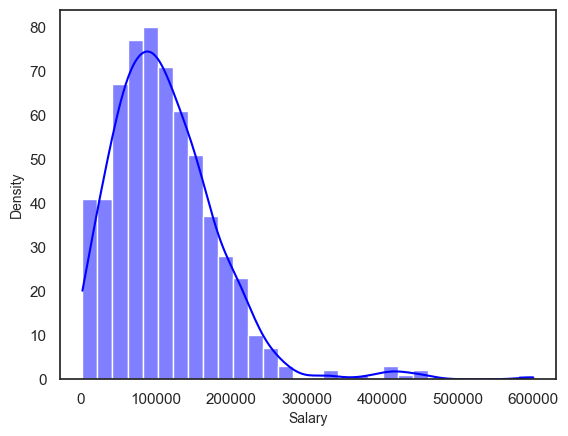

In [15]:
sns.set_theme(style="white")
sns.histplot(df['salary_in_usd'], kde=True, color='blue', bins=30)
plt.xlabel('Salary',fontsize=10)
plt.ylabel('Density',fontsize=10)